# Projet 
#### Sujet: Polarité et véracité d'avis d'hôtels
#### Etudiants: Marc Michoulier, Valid Kernuf, Ali Bhatti
---

## Prétraitement des données
---

Librairies que nous avons utilisées pour le prétraitement des données.

In [27]:
import os
import string
import numpy as np

from scipy.sparse.linalg import svds
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer

Chargement des données nécessaires à la modélisation.

In [28]:
#renvoie un dico avec une clé i en compteur d'avis qui résult en une liste comme suit: [String: contenu du .txt , Liste: [String: "positive" ou "negative", String: "truthful" ou "deceptive"]]
def ChargementDonnée(repertoire):
    i = 0
    RawData = {}
    #iter tout dossier d'un repertoire à partir d'une racine donné
    for racine, _, fichiers in os.walk(repertoire):
        #iter tout les .txt des fichiers vus
        for textfich in [f for f in fichiers if f.endswith(".txt")]:
            polarite = ([categorie for categorie in ["positive", "negative"] if categorie in racine] + [f"polarité non trouvé de {textfich} dans {racine}"])[0] #fallback pour erreur sans besoin de: "try" et "except"
            veracite = ([categorie for categorie in ["truthful", "deceptive"] if categorie in racine] + [f"véracité non trouvé de {textfich} dans {racine}"])[0]
            
            #mise a jour du dictionnaire
            with open(os.path.join(racine, textfich), "r", encoding="utf-8") as f:
                RawData[i] = [f.read(), [polarite, veracite]]
            i += 1

        #print(racine, fichiers)
    return RawData

donnees = ChargementDonnée("data")
print(donnees[0])

['We stayed at the Schicago Hilton for 4 days and 3 nights for a conference. I have to say, normally I am very easy going about amenities, cleanliness, and the like...however our experience at the Hilton was so awful I am taking the time to actually write this review. Truly, DO NOT stay at this hotel. When we arrived in our room, it was clear that the carpet hadn\'t been vacuumed. I figuered, "okay, it\'s just the carpet." Until I saw the bathroom! Although the bathroom had all the superficial indicators of housekeeping having recently cleaned (i.e., a paper band across the toilet, paper caps on the drinking glasses, etc., it was clear that no ACTUAL cleaning took place. There was a spot (probably urine!) on the toilet seat and, I kid you not, the remnants of a lip-smudge on the glass. I know people who have worked many years in the hotel industry and they always warned that lazy housekeeping will make things "appear" clean but in fact they make no effort to keep things sanitary. Well,

In [29]:
stopwords = ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours',
                'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', 'her', 'hers',
                'herself', 'it', 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves',
                'what', 'which', 'who', 'whom', 'this', 'that', 'these', 'those', 'am', 'is', 'are',
                'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does',
                'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until',
                'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into',
                'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down',
                'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here',
                'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more',
                'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so',
                'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', 'should', 'now','br']
pontuation = set(string.punctuation)

def NettoyageString(data):

    DocsNettoyees = "".join([mot if mot not in pontuation else " " for mot in data.lower()])
    DocsNettoyees = [mot for mot in DocsNettoyees.split() if mot not in stopwords]

    #racination
    racine = PorterStemmer()
    DocsNettoyees = [racine.stem(mot) for mot in DocsNettoyees]
    DocsNettoyees = ' '.join(mot for mot in DocsNettoyees)

    return DocsNettoyees

test = NettoyageString("Hello I love laughing!")
print(test)

hello love laugh


Nettoie les textes en supprimant la ponctuation, les mots vides (stopwords) et en appliquant une racinisation (stemming) pour préparer les données textuelles à l’analyse.

In [30]:
def Nettoyage(data):
  DonneesNettoyees = []
  for doc in data.values():
    DonneesNettoyees.append(NettoyageString(doc[0]))

  return DonneesNettoyees

DonneesNettoyees = Nettoyage(donnees)
print(DonneesNettoyees[0])

stay schicago hilton 4 day 3 night confer say normal easi go amen cleanli like howev experi hilton aw take time actual write review truli stay hotel arriv room clear carpet hadn vacuum figuer okay carpet saw bathroom although bathroom superfici indic housekeep recent clean e paper band across toilet paper cap drink glass etc clear actual clean took place spot probabl urin toilet seat kid remnant lip smudg glass know peopl work mani year hotel industri alway warn lazi housekeep make thing appear clean fact make effort keep thing sanitari well hilton proof call downstair complain sent chambermaid hour later frankli found room disgust hotel outsid room cavern unwelcom aw echo lobbi area creat migrain induc din rare eager leav place got home wash cloth whether worn skeevi accomod pleas favor stay clean hotel


Construction de la matrice TF-IDF à partir des textes nettoyés.

In [31]:
vec = TfidfVectorizer()
mat = vec.fit_transform(DonneesNettoyees)
print("Taille de la matrice TF-IDF: ",  mat.shape)
print("Taille: ", mat.size)
print("Densité de la matrice TF-IDF: ", 1-mat.size/(mat.shape[0]*mat.shape[1]))

Taille de la matrice TF-IDF:  (1600, 6682)
Taille:  96977
Densité de la matrice TF-IDF:  0.9909292689314576


Réduire la rareté de matrice en utilisant LSA

In [32]:
U, S, V = svds(mat, k=20)
X_app = np.linalg.multi_dot([U, np.diag(S), V])
X_app[X_app < 0] = 0

## Modèles
---

Librairies que nous avons utilisées pour crees les modeles.

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

Une fonction qui crée et utiliser un modèle et renvoie les resultats.

In [34]:
s = 42 #s le seed
def UtilisationNB(data, y, taille_test, seed):
    # Diviser les données pour tester et former le modèle.
    x_train, x_test, y_train, y_test = train_test_split(data, y, test_size = taille_test, random_state = seed, stratify= y)

    # Creer et utiliser un modèle
    clf = MultinomialNB()
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_test)

    return y_test, y_pred, clf

On teste une fonction de la polarité / veracité et utilisation de LSA ou non.

In [35]:
yPol = [donnees[a][1][0] for a in range(len(donnees))]
y_test_pol, y_pred_pol, clf_pol = UtilisationNB(mat, yPol, 0.4, s)

yPol_lsa = [donnees[a][1][0] for a in range(len(donnees))]
y_test_pol_lsa, y_pred_pol_lsa, clf_pol_lsa = UtilisationNB(X_app, yPol_lsa, 0.4, s)

yVer = [donnees[a][1][1] for a in range(len(donnees))] 
y_test_ver, y_pred_ver, clf_ver = UtilisationNB(mat, yVer, 0.4, s)

yVer_lsa = [donnees[a][1][1] for a in range(len(donnees))] 
y_test_ver_lsa, y_pred_ver_lsa, clf_ver_lsa = UtilisationNB(X_app, yVer_lsa, 0.4, s)

y_joint = [f"{donnees[a][1][0]}_{donnees[a][1][1]}" for a in range(len(donnees))]
y_test_joint, y_pred_joint, clf_joint = UtilisationNB(mat, y_joint, 0.4, s)

y_joint_lsa = [f"{donnees[a][1][0]}_{donnees[a][1][1]}" for a in range(len(donnees))]
y_test_joint_lsa, y_pred_joint_lsa, clf_joint_lsa = UtilisationNB(X_app, y_joint_lsa, 0.4, s)

## Tests
---

Librairies que nous avons utilisées pour tester les données.

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, accuracy_score

Cette fonction affiche la matrice de confusion, puis génère le rapport sur la précision de la classification et la qualité du modèle (précision, rappel, score f1) pour les prédictions.

In [37]:
def PrintMatrixAndMetrix(title, test, prediction, clf, color=plt.cm.Blues, x_rot=0, y_rot=0, tight=False):
    confMat = confusion_matrix(test, prediction, labels = clf.classes_)
    confMatDisp = ConfusionMatrixDisplay(confusion_matrix = confMat, display_labels = clf.classes_)
    confMatDisp.plot(cmap=color)
    plt.title(title)
    plt.xticks(rotation=x_rot)
    plt.yticks(rotation=y_rot)
    if (tight):
        plt.tight_layout()
    plt.show()

    print(f"\nAccuracy: {accuracy_score(test, prediction):.2%}\n")

    print("\nRapport de classification:")
    print(classification_report(test, prediction))

Résultats pour les modèles de polarité (avec et sans LSA)

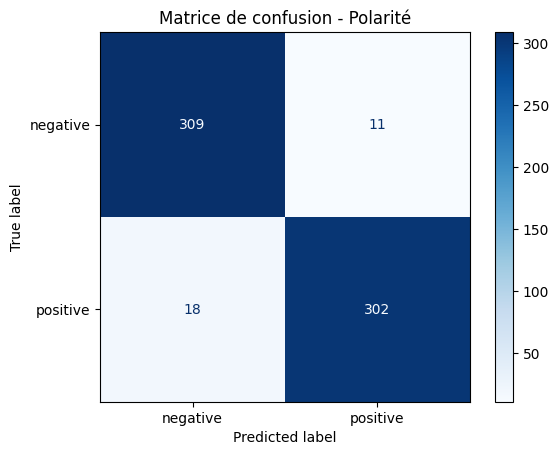


Accuracy: 95.47%


Rapport de classification:
              precision    recall  f1-score   support

    negative       0.94      0.97      0.96       320
    positive       0.96      0.94      0.95       320

    accuracy                           0.95       640
   macro avg       0.95      0.95      0.95       640
weighted avg       0.95      0.95      0.95       640



In [38]:
PrintMatrixAndMetrix("Matrice de confusion - Polarité", y_test_pol, y_pred_pol, clf_pol)

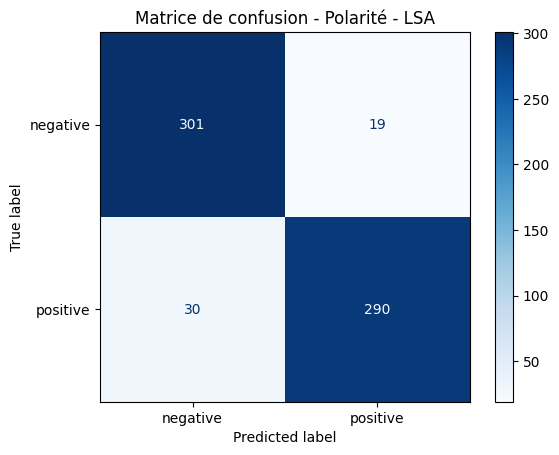


Accuracy: 92.34%


Rapport de classification:
              precision    recall  f1-score   support

    negative       0.91      0.94      0.92       320
    positive       0.94      0.91      0.92       320

    accuracy                           0.92       640
   macro avg       0.92      0.92      0.92       640
weighted avg       0.92      0.92      0.92       640



In [39]:
PrintMatrixAndMetrix("Matrice de confusion - Polarité - LSA", y_test_pol_lsa, y_pred_pol_lsa, clf_pol_lsa)

Résultats pour les modèles de véracité (avec et sans LSA)

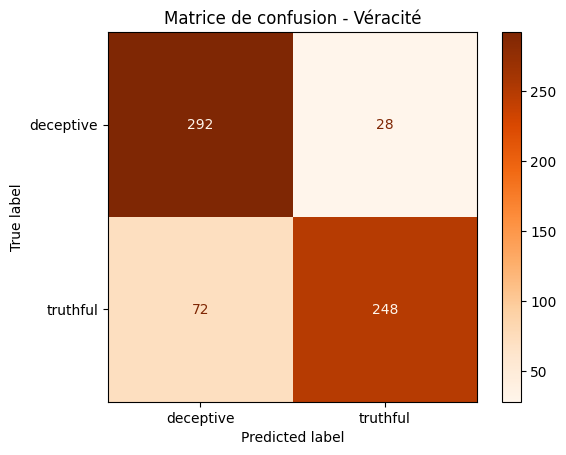


Accuracy: 84.38%


Rapport de classification:
              precision    recall  f1-score   support

   deceptive       0.80      0.91      0.85       320
    truthful       0.90      0.78      0.83       320

    accuracy                           0.84       640
   macro avg       0.85      0.84      0.84       640
weighted avg       0.85      0.84      0.84       640



In [40]:
PrintMatrixAndMetrix("Matrice de confusion - Véracité", y_test_ver, y_pred_ver, clf_ver, color = plt.cm.Oranges)

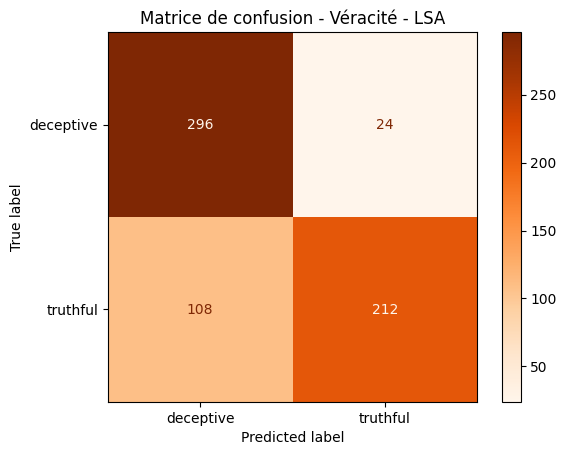


Accuracy: 79.38%


Rapport de classification:
              precision    recall  f1-score   support

   deceptive       0.73      0.93      0.82       320
    truthful       0.90      0.66      0.76       320

    accuracy                           0.79       640
   macro avg       0.82      0.79      0.79       640
weighted avg       0.82      0.79      0.79       640



In [41]:
PrintMatrixAndMetrix("Matrice de confusion - Véracité - LSA", y_test_ver_lsa, y_pred_ver_lsa, clf_ver_lsa, color = plt.cm.Oranges)

Résultats pour les modèles générals (avec et sans LSA)

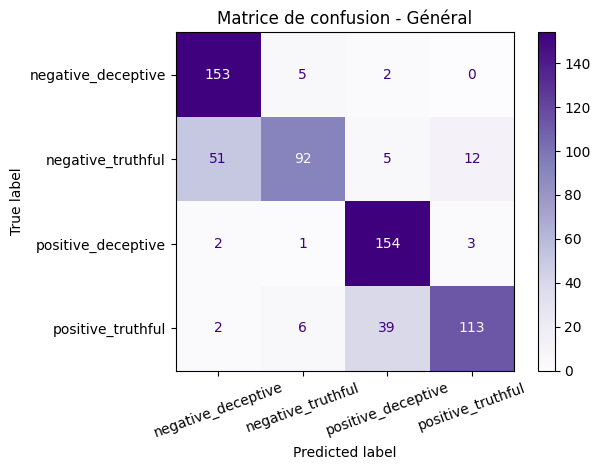


Accuracy: 80.00%


Rapport de classification:
                    precision    recall  f1-score   support

negative_deceptive       0.74      0.96      0.83       160
 negative_truthful       0.88      0.57      0.70       160
positive_deceptive       0.77      0.96      0.86       160
 positive_truthful       0.88      0.71      0.78       160

          accuracy                           0.80       640
         macro avg       0.82      0.80      0.79       640
      weighted avg       0.82      0.80      0.79       640



In [42]:
PrintMatrixAndMetrix("Matrice de confusion - Général", y_test_joint, y_pred_joint, clf_joint, color = plt.cm.Purples, x_rot=20, tight=True)

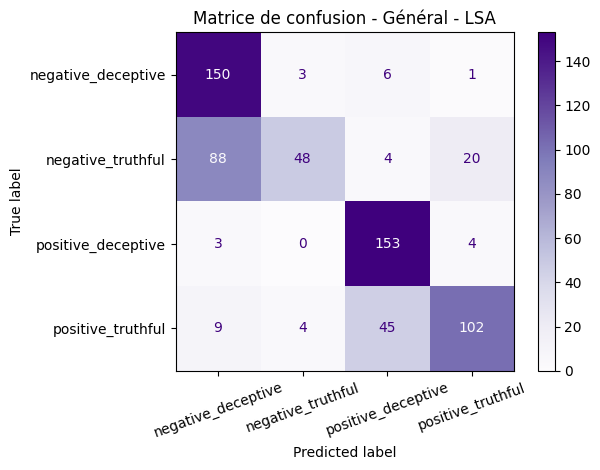


Accuracy: 70.78%


Rapport de classification:
                    precision    recall  f1-score   support

negative_deceptive       0.60      0.94      0.73       160
 negative_truthful       0.87      0.30      0.45       160
positive_deceptive       0.74      0.96      0.83       160
 positive_truthful       0.80      0.64      0.71       160

          accuracy                           0.71       640
         macro avg       0.75      0.71      0.68       640
      weighted avg       0.75      0.71      0.68       640



In [43]:
PrintMatrixAndMetrix("Matrice de confusion - Général - LSA", y_test_joint_lsa, y_pred_joint_lsa, clf_joint_lsa, color = plt.cm.Purples, x_rot=20, tight=True)

Comme on peut le voir les matrices avec LSA ont moins d'accuracy, par conséquant on continuera sans LSA

---
On fait une fonction pour généré les mots les plus dicriminatifs

In [44]:
def TrouveTermesDiscriminants(x, y, taille_test, seed, classe):
    DicoRes = {}
    y_test, y_pred, clf = UtilisationNB(x, y, taille_test, seed)

    #positif, négatif pour la polarité et vrai, faux pour la véracité
    if classe not in ["positif", "négatif", "vrai", "faux"]:
        raise NotImplementedError("Classe inconnue, essayer: positif, négatif, vrai ou faux")
    
    TermesPossibles = vec.get_feature_names_out()
    ValeursDiscriminatifs = clf.feature_log_prob_[1] - clf.feature_log_prob_[0]
    ValeursDiscriminatifsTriées = np.argsort(ValeursDiscriminatifs)[::-1 if ["positif", "négatif", "vrai", "faux"].index(classe) % 2 == 0 else 1]

    print("Top termes les plus discriminatifs {0}:".format(classe))
    for idx in ValeursDiscriminatifsTriées:
        DicoRes[TermesPossibles[idx]] = ValeursDiscriminatifs[idx]
    return DicoRes

In [45]:
TermesDiscriminantsPol = TrouveTermesDiscriminants(mat, yPol, 0.4, s, "positif")
print(TermesDiscriminantsPol)

Top termes les plus discriminatifs positif:
{'amaz': np.float64(1.9621405231627307), 'perfect': np.float64(1.8634176408682048), 'fantast': np.float64(1.6334619093723504), 'spaciou': np.float64(1.6082552374269143), 'wonder': np.float64(1.5943715299486279), 'love': np.float64(1.537488272544647), 'delici': np.float64(1.526198286103802), 'gorgeou': np.float64(1.464317003754739), 'shop': np.float64(1.4635394004999425), 'beauti': np.float64(1.4517819416339162), 'michigan': np.float64(1.430419401197649), 'excel': np.float64(1.4097666436823122), 'mile': np.float64(1.3923660609755864), 'comfort': np.float64(1.3871916236801178), 'highli': np.float64(1.3832236783345042), 'distanc': np.float64(1.3313476079626394), 'profession': np.float64(1.3143449902794968), 'great': np.float64(1.297751446033474), 'defin': np.float64(1.2832433149733067), 'spotless': np.float64(1.2749603926366841), 'awesom': np.float64(1.2724948881927851), 'enjoy': np.float64(1.2658411088621317), 'superb': np.float64(1.26315890578

In [46]:
TermesDiscriminantsPol = TrouveTermesDiscriminants(mat, yPol, 0.4, s, "négatif")
print(TermesDiscriminantsPol)

Top termes les plus discriminatifs négatif:
{'rude': np.float64(-2.08881312534334), 'dirti': np.float64(-1.843436966555883), 'call': np.float64(-1.739284567542704), 'told': np.float64(-1.7365019262017576), 'final': np.float64(-1.7162963748811997), 'disappoint': np.float64(-1.5275647072417167), 'smell': np.float64(-1.4554478314021768), 'manag': np.float64(-1.430920743387512), 'poor': np.float64(-1.418841057440706), 'terribl': np.float64(-1.4056720516817585), 'suppos': np.float64(-1.4035434493136734), 'stain': np.float64(-1.398829326119218), 'wall': np.float64(-1.3856521136221165), 'someon': np.float64(-1.3729302034645468), 'apolog': np.float64(-1.3197310582860018), 'smoke': np.float64(-1.3187407381834726), 'phone': np.float64(-1.3107006956451688), 'uncomfort': np.float64(-1.30170054936102), 'avoid': np.float64(-1.2926145113846026), 'complain': np.float64(-1.2906832006495188), 'carpet': np.float64(-1.2773265271635026), 'key': np.float64(-1.2752675397858928), 'worst': np.float64(-1.270759

In [47]:
TermesDiscriminantsVer = TrouveTermesDiscriminants(mat, yVer, 0.4, s, "vrai")
print(TermesDiscriminantsVer)

Top termes les plus discriminatifs vrai:
{'pricelin': np.float64(1.655251663679124), 'elev': np.float64(1.602986862172953), 'block': np.float64(1.5490670094631795), 'quiet': np.float64(1.278011851823309), 'updat': np.float64(1.2765537381397785), 'properti': np.float64(1.1735370908430074), 'larger': np.float64(1.1257891295710785), 'bottl': np.float64(1.0892200222970034), 'ave': np.float64(1.0858415921360445), 'review': np.float64(1.0771331276039753), 'directli': np.float64(1.0528239952124814), 'michigan': np.float64(1.0506714422979337), 'hancock': np.float64(1.0406174551543774), 'loop': np.float64(1.0148684724474766), 'larg': np.float64(1.0110981138398287), 'small': np.float64(0.9669609322873693), 'european': np.float64(0.9396426683100589), 'upgrad': np.float64(0.931827695596299), 'doorman': np.float64(0.9277711536460806), 'street': np.float64(0.9261061119892737), 'tini': np.float64(0.9006010549341479), 'compar': np.float64(0.8969415316663163), 'juli': np.float64(0.8969064578655956), 's

In [48]:
TermesDiscriminantsVer =  TrouveTermesDiscriminants(mat, yVer, 0.4, s, "faux")
print(TermesDiscriminantsVer)

Top termes les plus discriminatifs faux:
{'luxuri': np.float64(-1.6383319418322415), 'pet': np.float64(-1.5297708749289463), 'relax': np.float64(-1.2868403261535715), 'spa': np.float64(-1.2618462339932588), 'massag': np.float64(-1.152004316369169), 'atmospher': np.float64(-1.122865471645703), 'meal': np.float64(-1.0886467257844092), 'millennium': np.float64(-1.085048848877019), 'smell': np.float64(-1.064252974229655), 'soon': np.float64(-0.986168474346309), 'dine': np.float64(-0.9554264000900234), 'dog': np.float64(-0.950562115776755), 'televis': np.float64(-0.9465292816984476), 'settl': np.float64(-0.9198314002057995), 'wed': np.float64(-0.8907234103534734), 'decis': np.float64(-0.8709832321894364), 'yet': np.float64(-0.8698439172102654), 'hadn': np.float64(-0.8668332665279621), 'unpleas': np.float64(-0.8654143814956541), 'anyon': np.float64(-0.8530434343531281), 'visit': np.float64(-0.8389260527664), 'regenc': np.float64(-0.8360976570339993), 'husband': np.float64(-0.8323691034950755

In [49]:
import tkinter as tk
from scipy.sparse import csr_matrix

def MatriceCreuseCompressée(phrase, terminologie):
    tokens = phrase.lower().split()
    idxs = [terminologie[w] for w in tokens if w in terminologie]
    if not idxs:
        return csr_matrix((1, len(terminologie)), dtype=float)

    data = np.ones(len(idxs))
    indices = np.array(idxs, dtype=int)
    indpointeur = np.array([0, len(idxs)], dtype=int)
    return csr_matrix((data, indices, indpointeur), shape=(1, len(terminologie)))

def Action(event):
    phrase = ZonePhrase.get().strip()
    if not phrase:
        LabelPol.config(text="Polarité: vide")
        LabelVer.config(text="Véracité: vide")
        listbox.delete(0, tk.END)
        return

    phrase_clean = NettoyageString(phrase)
    XNew = MatriceCreuseCompressée(phrase_clean, vec.vocabulary_)

    # Prédictions globales
    label_p = clf_pol.predict(XNew)[0]
    proba_p = clf_pol.predict_proba(XNew)[0]
    LabelPol.config(
        text=f"Polarité: {label_p}   (P+={proba_p[1]:.1%}, P–={proba_p[0]:.1%})"
    )

    label_v = clf_ver.predict(XNew)[0]
    proba_v = clf_ver.predict_proba(XNew)[0]
    LabelVer.config(
        text=f"Véracité: {label_v}   (P+={proba_v[1]:.1%}, P–={proba_v[0]:.1%})"
    )

    # Mise à jour de la Listbox des tokens
    listbox.delete(0, tk.END)
    seen = set()
    for w in phrase_clean.lower().split():
        if w in seen:
            continue
        seen.add(w)
        wp = TermesDiscriminantsPol.get(w, None)
        wv = TermesDiscriminantsVer.get(w, None)
        if wp is not None or wv is not None:
            listbox.insert(
                tk.END,
                f"{w:>12s}  ↦  pol: {wp or 0:.3f}  ver: {wv or 0:.3f}"
            )
        else:
            listbox.insert(tk.END, f"{w:>12s} est inconnue")

# --- Construction de l’UI TKinter ---
root = tk.Tk()
root.title("Test de classes de phrase avec Naïve Bayes")

tk.Label(root, text="Rentrez une phrase :").pack(pady=(10, 0))
ZonePhrase = tk.Entry(root, width=60)
ZonePhrase.pack(padx=10, pady=5)
ZonePhrase.bind("<KeyRelease>", Action)

LabelPol = tk.Label(root, text="Polarité: vide")
LabelPol.pack(pady=(5, 0))
LabelVer = tk.Label(root, text="Véracité: vide")
LabelVer.pack(pady=(5, 10))

tk.Label(root, text="Tokens détectés et poids :").pack()
listbox = tk.Listbox(root, width=60, height=8)
listbox.pack(padx=10, pady=(0, 10))

root.mainloop()